# Food Safety Intelligence — Dataset Overview

**Goal of this notebook:** load and lightly profile the four public datasets that power our Chicago food-safety risk model, so the team can see what we have to work with on day 1.

| # | Dataset | Why it's in the model |
|---|---|---|
| 1 | Chicago **Food Inspections** (`4ijn-s7e5`) | Ground-truth labels (Pass / Fail / violations) — the prediction target lives here |
| 2 | Chicago **311 Service Requests** (`v6vf-nfxy`) | Neighborhood signals: rodents, sanitation, restaurant complaints, illegal dumping |
| 3 | Chicago **Business Licenses — Current Active** (`uupf-x98q`) | Today's universe of licensed establishments (with lat/lon, neighborhood) |
| 4 | Chicago **Business Licenses — Historical** (`vgg9-bn8p`) | License history: when each license started, expired, renewed, status changes |

**How to read this notebook:** every dataset section follows the same shape — *fetch → cache → peek → profile*. We cache each pull to `../data/raw/*.parquet` so re-runs are instant and teammates can work offline.

**Runtime:** ~3–6 minutes the first time (network-bound), seconds on every re-run.

## 0. Setup

Shared imports and the single fetch helper every section uses. All four datasets live on the same Socrata (SODA) API, so one paginating function covers them all.

In [1]:
from pathlib import Path
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Cache directory — relative to this notebook's location.
DATA_DIR = Path('../data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# All four datasets are served by the City of Chicago Socrata portal.
SODA_BASE = 'https://data.cityofchicago.org/resource'

DATASETS = {
    'inspections':         '4ijn-s7e5',   # Food inspections
    'complaints_311':      'v6vf-nfxy',   # 311 service requests
    'licenses_current':    'uupf-x98q',   # Business licenses — current active
    'licenses_historical': 'vgg9-bn8p',   # Business licenses — historical
}

In [2]:
def fetch_soda(dataset_id, where=None, select=None, order=None,
               page_size=50_000, max_pages=200, timeout=180,
               max_retries=4, verbose=True):
    """Paginate a SODA endpoint with retry + backoff and return a single DataFrame.

    Resilience matters: a single 120s timeout on page 11 would kill 500k rows
    of already-fetched data. We now:
      - bump per-request timeout to 180s
      - retry transient ReadTimeout / ConnectionError with exponential backoff
      - request gzip so big payloads come back faster

    For datasets where the *offset itself* is the bottleneck (311 past ~500k rows),
    use fetch_soda_keyset below — it pages by a date cursor instead of $offset.
    """
    url = f'{SODA_BASE}/{dataset_id}.json'
    frames = []
    for page in range(max_pages):
        params = {'$limit': page_size, '$offset': page * page_size}
        if where:  params['$where']  = where
        if select: params['$select'] = select
        if order:  params['$order']  = order

        for attempt in range(max_retries):
            try:
                t0 = time.time()
                r = requests.get(url, params=params, timeout=timeout,
                                 headers={'Accept-Encoding': 'gzip'})
                r.raise_for_status()
                elapsed = time.time() - t0
                break
            except (requests.Timeout, requests.ConnectionError) as e:
                if attempt == max_retries - 1:
                    raise
                wait = 5 * (2 ** attempt)  # 5, 10, 20, 40s
                if verbose:
                    print(f'  page {page+1} attempt {attempt+1} failed ({type(e).__name__}); retry in {wait}s')
                time.sleep(wait)

        chunk = pd.DataFrame(r.json())
        if chunk.empty:
            break
        frames.append(chunk)
        if verbose:
            cum = sum(len(f) for f in frames)
            print(f'  page {page+1}: +{len(chunk):,} rows (cum {cum:,}, {elapsed:.1f}s)')
        if len(chunk) < page_size:
            break
        time.sleep(0.2)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _safe_dedupe(df, dedupe_on=None, verbose=True):
    """Dedupe robust to unhashable columns (e.g. SODA's nested 'location' dicts).

    - If `dedupe_on` is given, dedupe on that key column (fast + unambiguous).
    - Else dedupe on the subset of hashable columns (drops dicts/lists from the key).
    """
    if dedupe_on:
        return df.drop_duplicates(subset=[dedupe_on])
    # Sample-check the first 200 rows to find unhashable columns cheaply.
    sample = df.head(200)
    unhashable = [
        c for c in df.columns
        if sample[c].dropna().apply(lambda x: isinstance(x, (dict, list))).any()
    ]
    if unhashable:
        if verbose:
            print(f'  dedupe: ignoring unhashable cols {unhashable}')
        hashable = [c for c in df.columns if c not in unhashable]
        return df.drop_duplicates(subset=hashable)
    return df.drop_duplicates()


def fetch_soda_keyset(dataset_id, cursor_col, cursor_start,
                      where_extra=None, page_size=50_000, max_pages=500,
                      timeout=180, max_retries=4, dedupe_on=None,
                      shard_dir=None, verbose=True):
    """Keyset pagination — pages by `cursor_col >= last_value` instead of $offset.

    Why: $offset is O(offset) on Socrata. Past ~500k matching rows the server
    starts timing out. Keyset pagination keeps every page fast regardless of depth.

    Resilience: if `shard_dir` is given, each page is written to a separate parquet
    shard there *immediately after fetch*. If anything later fails (e.g. dedupe),
    the next call resumes from the highest cursor value already on disk — we don't
    re-fetch 15 minutes of data.

    Dedupe: when many rows share the same cursor value across a page boundary,
    `>=` would re-fetch them, so we always dedupe at the end. `dedupe_on` lets
    the caller name a primary key column (e.g. 'sr_number') for cleaner semantics
    when the table has unhashable nested columns.
    """
    url = f'{SODA_BASE}/{dataset_id}.json'
    cursor = cursor_start
    shards = []

    # Resume from existing shards if any exist.
    if shard_dir is not None:
        shard_dir = Path(shard_dir)
        shard_dir.mkdir(parents=True, exist_ok=True)
        existing = sorted(shard_dir.glob('page_*.parquet'))
        if existing:
            shards = existing
            last = pd.read_parquet(existing[-1])
            cursor = str(last[cursor_col].max())
            if verbose:
                cum = sum(len(pd.read_parquet(s)) for s in shards)
                print(f'  resuming from {len(shards)} shard(s): {cum:,} rows, cursor → {cursor[:19]}')

    start_page = len(shards)
    for page in range(start_page, max_pages):
        where_parts = [f"{cursor_col} >= '{cursor}'"]
        if where_extra:
            where_parts.append(f'({where_extra})')
        params = {
            '$where': ' AND '.join(where_parts),
            '$order': f'{cursor_col} ASC',
            '$limit': page_size,
        }
        for attempt in range(max_retries):
            try:
                t0 = time.time()
                r = requests.get(url, params=params, timeout=timeout,
                                 headers={'Accept-Encoding': 'gzip'})
                r.raise_for_status()
                elapsed = time.time() - t0
                break
            except (requests.Timeout, requests.ConnectionError) as e:
                if attempt == max_retries - 1:
                    raise
                wait = 5 * (2 ** attempt)
                if verbose:
                    print(f'  page {page+1} attempt {attempt+1} failed ({type(e).__name__}); retry in {wait}s')
                time.sleep(wait)

        chunk = pd.DataFrame(r.json())
        if chunk.empty:
            break

        # Persist this page to disk immediately so a downstream crash doesn't lose it.
        if shard_dir is not None:
            shard_path = shard_dir / f'page_{page:04d}.parquet'
            chunk.astype({c: 'string' for c in chunk.select_dtypes('object').columns}) \
                 .to_parquet(shard_path, index=False)
            shards.append(shard_path)

        if verbose:
            cum_pages = page + 1
            print(f'  page {cum_pages}: +{len(chunk):,} rows (cursor={str(cursor)[:10]}, {elapsed:.1f}s)')
        if len(chunk) < page_size:
            break
        cursor = chunk[cursor_col].iloc[-1]
        time.sleep(0.2)

    if shards:
        out = pd.concat([pd.read_parquet(s) for s in shards], ignore_index=True)
    else:
        return pd.DataFrame()

    before = len(out)
    out = _safe_dedupe(out, dedupe_on=dedupe_on, verbose=verbose)
    if verbose and len(out) != before:
        print(f'  after dedupe: {len(out):,} rows (removed {before - len(out):,})')

    # On clean success, clean up the shard dir.
    if shard_dir is not None:
        for s in shards:
            s.unlink(missing_ok=True)
        try:
            shard_dir.rmdir()
        except OSError:
            pass  # not empty for some reason — leave it

    return out


def load_or_fetch(name, fetch_fn):
    """Load a cached parquet if present, otherwise run fetch_fn() and cache it.

    Teammates: delete the parquet under data/raw/ to force a refresh.
    """
    cache = DATA_DIR / f'{name}.parquet'
    if cache.exists():
        print(f'✓ loading {name} from cache: {cache}')
        return pd.read_parquet(cache)
    print(f'↻ fetching {name} from API...')
    df = fetch_fn()
    df = df.astype({c: 'string' for c in df.select_dtypes('object').columns})
    df.to_parquet(cache, index=False)
    print(f'  saved → {cache}  ({len(df):,} rows)')
    return df


def peek(df, name):
    """Standard one-page profile we print for every dataset."""
    print(f'=== {name} ===')
    print(f'shape:   {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'memory:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print(f'columns: {list(df.columns)}')
    print('\n— missing values (top 10) —')
    miss = df.isna().mean().sort_values(ascending=False).head(10)
    print((miss * 100).round(2).astype(str) + '%')
    print('\n— head(3) —')
    return df.head(3)

## 1. Food Inspections — full history (2010 → present)

Source: https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5

This is the **labeled outcomes** table — every row is one inspection visit. Key columns:
- `inspection_id`, `license_` — joins to business licenses
- `inspection_date`, `inspection_type` (Canvass / Complaint / License / Re-Inspection)
- `results` — Pass / Pass w/ Conditions / Fail / Out of Business / No Entry — **the prediction target**
- `violations` — `|`-separated text, each chunk prefixed with a numbered code (1–29 are priority / 'critical' violations)
- `risk`, `facility_type`, `latitude`, `longitude`

In [3]:
def _fetch_inspections():
    return fetch_soda(
        DATASETS['inspections'],
        order='inspection_date ASC, inspection_id ASC',
    )

inspections = load_or_fetch('inspections', _fetch_inspections)

# Drop Socrata-internal computed_region columns + nested location.
inspections = inspections.loc[:, ~inspections.columns.str.startswith(':@computed_region')]
if 'location' in inspections.columns:
    inspections = inspections.drop(columns=['location'])

# Coerce types — everything comes off SODA as string.
inspections['inspection_date'] = pd.to_datetime(inspections['inspection_date'])
inspections['latitude']  = pd.to_numeric(inspections['latitude'],  errors='coerce')
inspections['longitude'] = pd.to_numeric(inspections['longitude'], errors='coerce')

peek(inspections, 'Food Inspections')

↻ fetching inspections from API...


  page 1: +50,000 rows (cum 50,000, 6.7s)


  page 2: +50,000 rows (cum 100,000, 8.6s)


  page 3: +50,000 rows (cum 150,000, 8.6s)


  page 4: +50,000 rows (cum 200,000, 28.0s)


...

  saved → ../data/raw/inspections.parquet  (311,775 rows)


=== Food Inspections ===
shape:   311,775 rows × 16 cols


memory:  521.3 MB
columns: ['inspection_id', 'dba_name', 'aka_name', 'license_', 'facility_type', 'risk', 'address', 'city', 'state', 'zip', 'inspection_date', 'inspection_type', 'results', 'latitude', 'longitude', 'violations']

— missing values (top 10) —


violations       28.11%
facility_type     1.71%
aka_name          0.78%
latitude          0.34%
longitude         0.34%
city              0.06%
risk              0.03%
state             0.02%
zip               0.01%
license_          0.01%
dtype: object

— head(3) —


,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,latitude,longitude,violations
0,52234,Cafe 608,Cafe 608,2013328,Restaurant,Risk 1 (High),608 W BARRY AVE,CHICAGO,IL,60657,2010-01-04,License Re-Inspection,Pass,41.938007,-87.644755,<NA>
1,67732,WOLCOTT'S,TROQUET,1992039,Restaurant,Risk 1 (High),1834 W MONTROSE AVE,CHICAGO,IL,60613,2010-01-04,License Re-Inspection,Pass,41.961606,-87.675967,<NA>
2,67733,WOLCOTT'S,TROQUET,1992040,Restaurant,Risk 1 (High),1834 W MONTROSE AVE,CHICAGO,IL,60613,2010-01-04,License Re-Inspection,Pass,41.961606,-87.675967,<NA>


In [4]:
print('Date range:', inspections['inspection_date'].min().date(),
      '→', inspections['inspection_date'].max().date())
print(f'\nUnique licenses (facilities): {inspections["license_"].nunique():,}')
print(f'Inspections per year (last 5):')
print(inspections.assign(year=inspections['inspection_date'].dt.year)
      .groupby('year').size().tail(5).to_string())

print('\n--- results distribution ---')
print(inspections['results'].value_counts(dropna=False).to_string())

Date range: 2010-01-04 → 2026-06-12

Unique licenses (facilities): 48,653
Inspections per year (last 5):
year
2022    16936
2023    18261
2024    19226
2025    19202
2026     7431

--- results distribution ---


results
Pass                    161313
Fail                     60045
Pass w/ Conditions       46328
Out of Business          25636
No Entry                 13904
Not Ready                 4454
Business Not Located        95


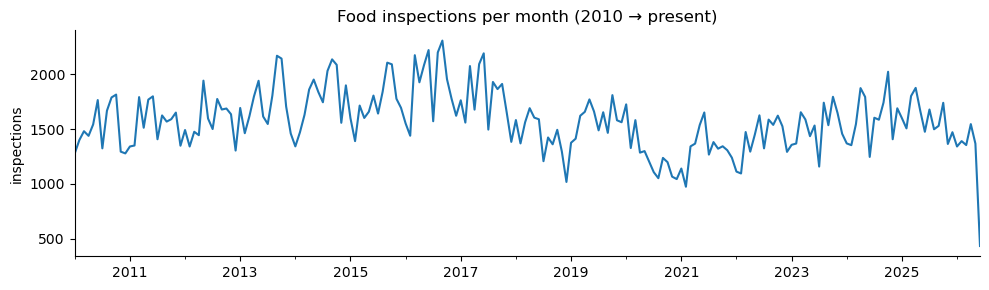

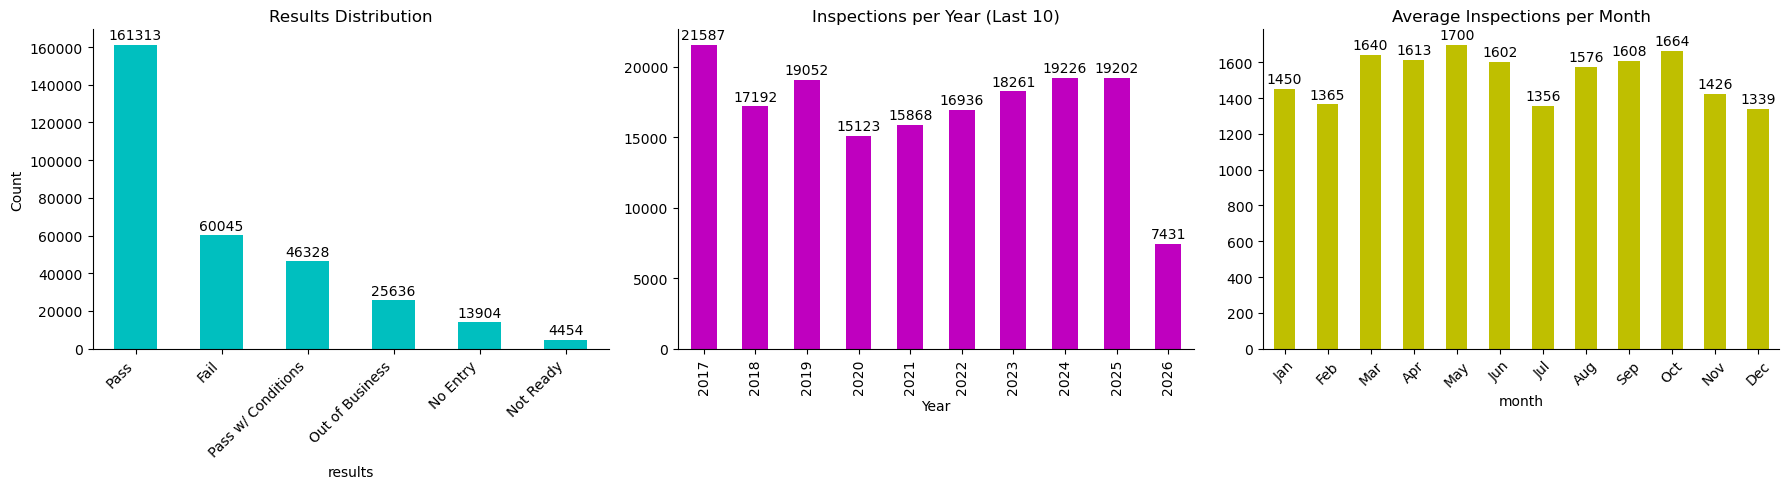

In [28]:
# Quick visual — inspections per month over the full history.
ax = (inspections.assign(m=inspections['inspection_date'].dt.to_period('M'))
      .groupby('m').size().plot(title='Food inspections per month (2010 → present)', figsize=(10,3)))
ax.set_xlabel(''); ax.set_ylabel('inspections')
plt.tight_layout(); plt.show()

# --- NEW: Additional Distribution Charts ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Results Distribution
res_dist = inspections['results'].value_counts().head(6)
ax1 = res_dist.plot(kind='bar', ax=axes[0], color='c', title='Results Distribution')
for c in ax1.containers: ax1.bar_label(c, padding=2)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Count')

# Inspections per Year
yearly_counts = inspections.assign(year=inspections['inspection_date'].dt.year).groupby('year').size()
ax2 = yearly_counts.tail(10).plot(kind='bar', ax=axes[1], color='m', title='Inspections per Year (Last 10)')
for c in ax2.containers: ax2.bar_label(c, padding=2)
ax2.set_xlabel('Year')

# Average Inspections per Month (Seasonality)
num_years = inspections['inspection_date'].dt.year.nunique()
monthly_avg = inspections.assign(month=inspections['inspection_date'].dt.month).groupby('month').size() / num_years
ax3 = monthly_avg.plot(kind='bar', ax=axes[2], color='y', title='Average Inspections per Month')
for c in ax3.containers: ax3.bar_label(c, fmt='%.0f', padding=2)
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

plt.tight_layout()
plt.show()

### Inspection outcome mix and modeling relevance

The inspection table is our label source, so before joining any external data we need to understand how many rows represent true food-safety outcomes versus administrative/non-inspection outcomes. This also helps explain why later notebooks drop or mask rows like `No Entry`, `Out of Business`, and `Not Ready` before training.

In [6]:
# Outcome mix: which inspection results are modelable food-safety outcomes?
MODELABLE_RESULTS = {'Pass', 'Pass w/ Conditions', 'Fail'}

result_summary = (
    inspections['results']
    .fillna('Missing')
    .value_counts()
    .rename_axis('results')
    .reset_index(name='n')
)

result_summary['share'] = result_summary['n'] / result_summary['n'].sum()
result_summary['is_modelable'] = result_summary['results'].isin(MODELABLE_RESULTS)

result_summary

,results,n,share,is_modelable
0,Pass,161313,0.517402,True
1,Fail,60045,0.192591,True
2,Pass w/ Conditions,46328,0.148594,True
3,Out of Business,25636,0.082226,False
4,No Entry,13904,0.044596,False
5,Not Ready,4454,0.014286,False
6,Business Not Located,95,0.000305,False


In [7]:
# Yearly inspection volume and outcome rates among modelable inspections.
MODELABLE_RESULTS = {'Pass', 'Pass w/ Conditions', 'Fail'}

inspection_year_summary = (
    inspections
    .assign(
        year=inspections['inspection_date'].dt.year,
        is_fail=inspections['results'].eq('Fail'),
        is_conditional=inspections['results'].eq('Pass w/ Conditions'),
        is_modelable=inspections['results'].isin(MODELABLE_RESULTS),
    )
    .groupby('year')
    .agg(
        n_inspections=('inspection_id', 'size'),
        n_modelable=('is_modelable', 'sum'),
        modelable_share=('is_modelable', 'mean'),
        unique_licenses=('license_', 'nunique'),
    )
)

modelable_by_year = (
    inspections[inspections['results'].isin(MODELABLE_RESULTS)]
    .assign(
        year=lambda d: d['inspection_date'].dt.year,
        is_fail=lambda d: d['results'].eq('Fail'),
        is_conditional=lambda d: d['results'].eq('Pass w/ Conditions'),
    )
    .groupby('year')
    .agg(
        fail_rate=('is_fail', 'mean'),
        conditional_pass_rate=('is_conditional', 'mean'),
    )
)

inspection_year_summary = inspection_year_summary.join(modelable_by_year)

inspection_year_summary.tail(10).round(3)

,n_inspections,n_modelable,modelable_share,unique_licenses,fail_rate,conditional_pass_rate
year,,,,,,
2017,21587,18499,0.857,12958,0.223,0.116
2018,17192,14849,0.864,11015,0.223,0.347
2019,19052,16121,0.846,12593,0.224,0.493
2020,15123,12600,0.833,10149,0.233,0.312
2021,15868,13139,0.828,10366,0.231,0.242
2022,16936,14286,0.844,10983,0.249,0.175
2023,18261,15413,0.844,11644,0.249,0.153
2024,19226,15994,0.832,12466,0.218,0.163
2025,19202,16057,0.836,12132,0.211,0.142


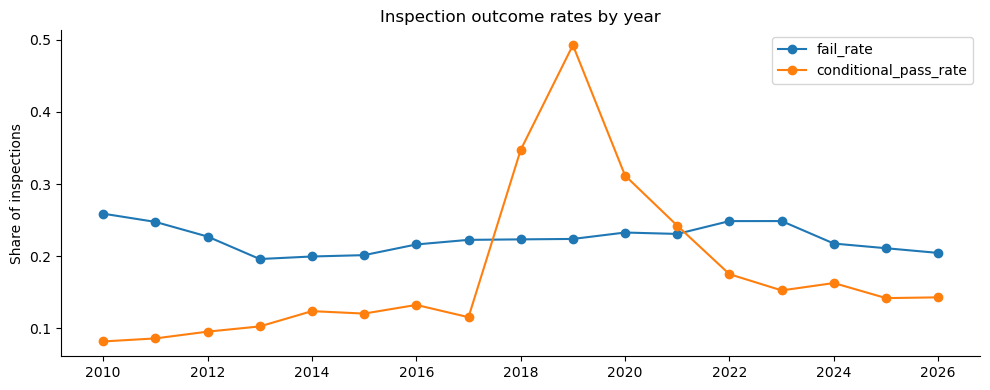

In [8]:
# Visual: outcome rate over time.
ax = inspection_year_summary[['fail_rate', 'conditional_pass_rate']].plot(
    marker='o',
    title='Inspection outcome rates by year'
)
ax.set_xlabel('')
ax.set_ylabel('Share of inspections')
plt.tight_layout()
plt.show()

### Inspections by Risk Level

Let's look at how the failure rate changes based on the city's assigned risk category (Risk 1 High, Risk 2 Medium, Risk 3 Low).

--- Failure Rates by Risk Level ---


risk
Risk 3 (Low)       21.0%
Risk 1 (High)      19.1%
Risk 2 (Medium)    19.0%
All                 6.3%
dtype: object

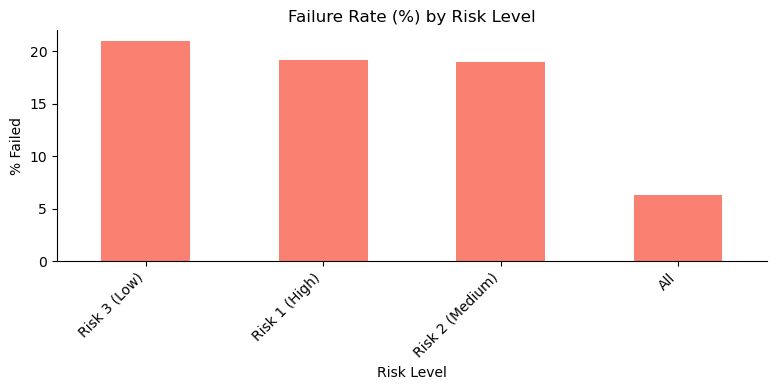


--- Statistical Summary of Violation Counts ---


,count,mean,std,min,25%,50%,75%,max
violation_count,311775.0,3.246017,3.391579,0.0,0.0,3.0,5.0,40.0


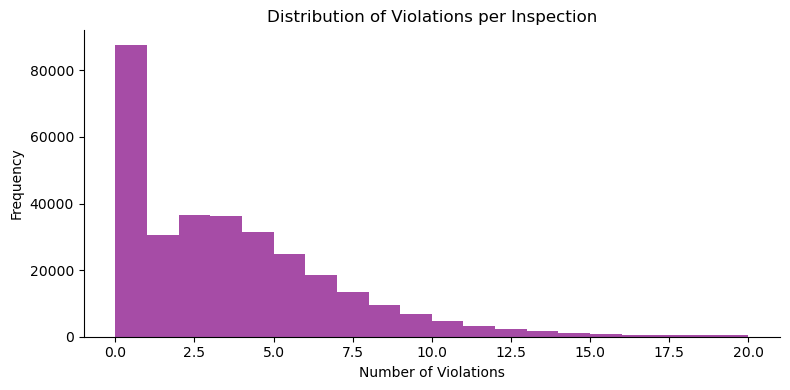

/tmp/ipykernel_1779/1951473078.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_fails = inspections.groupby('month').apply(lambda x: (x['results'] == 'Fail').mean() * 100)


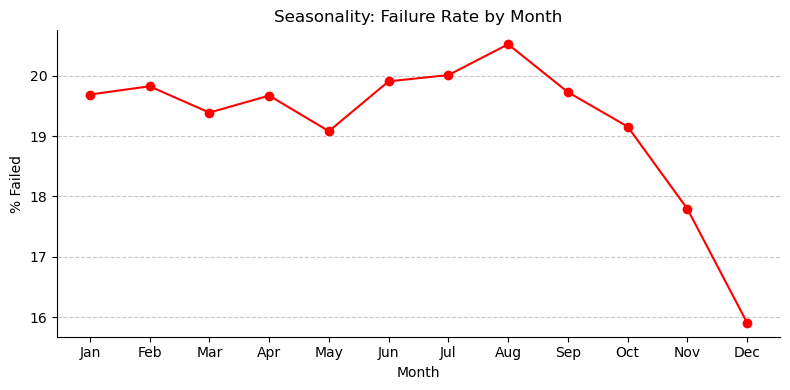

In [29]:
# Calculate and plot failure rates by Risk category
# Note: These rates are the percentage of inspections WITHIN each risk category that failed.
# They do not add up to 100% because they are independent group probabilities.
risk_counts = inspections.groupby('risk').size()
fail_counts = inspections[inspections['results'] == 'Fail'].groupby('risk').size()

fail_rates = (fail_counts / risk_counts * 100).dropna().sort_values(ascending=False)

print("--- Failure Rates by Risk Level ---")
display(fail_rates.round(1).astype(str) + '%')

ax = fail_rates.plot(kind='bar', title='Failure Rate (%) by Risk Level', color='salmon', figsize=(8, 4))
ax.set_ylabel('% Failed')
ax.set_xlabel('Risk Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Statistical EDA: Violations per Inspection ---
# Count the number of violations by splitting the string. If NA, it's 0.
inspections['violation_count'] = inspections['violations'].fillna('').apply(lambda x: len(x.split('|')) if x else 0)
print("\n--- Statistical Summary of Violation Counts ---")
display(inspections['violation_count'].describe().to_frame().T)

ax2 = inspections['violation_count'].plot.hist(bins=20, range=(0, 20), title='Distribution of Violations per Inspection', color='purple', alpha=0.7, figsize=(8, 4))
ax2.set_xlabel('Number of Violations')
plt.tight_layout()
plt.show()

# --- Time Series EDA: Seasonality of Failures ---
# Look at failure rates by month of the year to check for seasonality
inspections['month'] = inspections['inspection_date'].dt.month
monthly_fails = inspections.groupby('month').apply(lambda x: (x['results'] == 'Fail').mean() * 100)

ax3 = monthly_fails.plot(kind='line', marker='o', title='Seasonality: Failure Rate by Month', figsize=(8,4), color='red')
ax3.set_xlabel('Month')
ax3.set_ylabel('% Failed')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Inspection Types & Class Imbalance
Let's look at how failure rates differ by the type of inspection. Mixing Canvass (routine) and Complaint-driven inspections without accounting for the trigger could bias the model.

--- Results Breakdown by Inspection Type ---


results,Pass,Pass w/ Conditions,Fail,Out of Business
inspection_type,,,,
Canvass,46.0%,16.6%,18.3%,15.6%
Canvass Re-Inspection,78.1%,12.0%,8.6%,0.3%
Complaint,39.7%,21.5%,33.1%,0.4%
License,48.7%,9.1%,30.0%,0.2%
License Re-Inspection,77.8%,10.5%,10.8%,0.1%


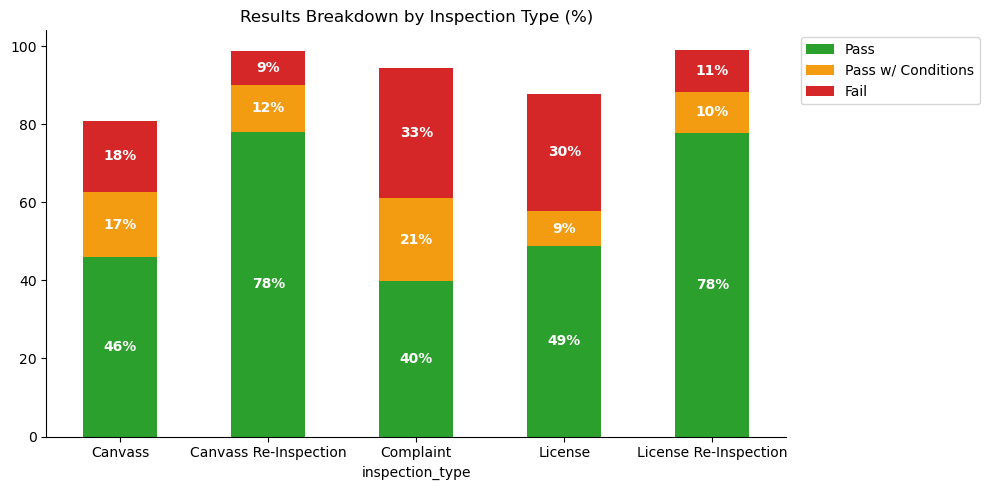

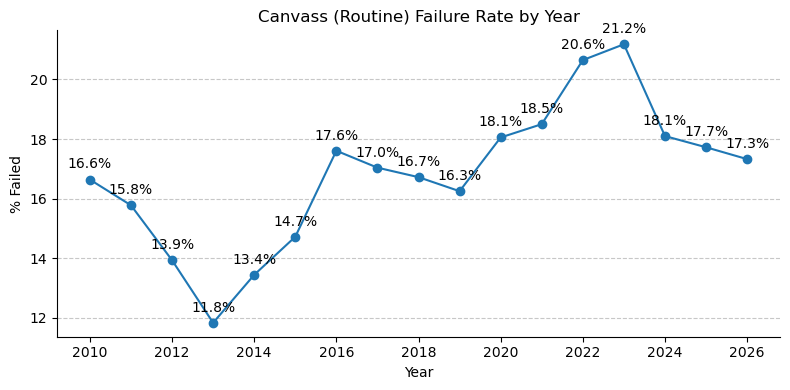

In [30]:
# Top 5 inspection types vs. Results
top_types = inspections['inspection_type'].value_counts().head(5).index

print("--- Results Breakdown by Inspection Type ---")
type_res = pd.crosstab(
    inspections[inspections['inspection_type'].isin(top_types)]['inspection_type'],
    inspections['results'],
    normalize='index'
) * 100

display(type_res[['Pass', 'Pass w/ Conditions', 'Fail', 'Out of Business']].round(1).astype(str) + '%')

# Visualizing the table with a stacked bar chart
ax_stack = type_res[['Pass', 'Pass w/ Conditions', 'Fail']].plot(kind='bar', stacked=True, figsize=(10, 5), title='Results Breakdown by Inspection Type (%)', color=['#2ca02c', '#f39c12', '#d62728'])
for c in ax_stack.containers:
    ax_stack.bar_label(c, fmt='%.0f%%', label_type='center', color='white', weight='bold')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Yearly failure rate for Canvass only
canvass = inspections[inspections['inspection_type'].str.lower().str.contains('canvass', na=False)]
yearly_canvass_fail = canvass.groupby(canvass['inspection_date'].dt.year).apply(lambda x: (x['results'] == 'Fail').mean() * 100)

ax = yearly_canvass_fail.plot(kind='line', marker='o', title='Canvass (Routine) Failure Rate by Year', figsize=(8,4))
ax.set_ylabel('% Failed')
ax.set_xlabel('Year')
for x, y in zip(yearly_canvass_fail.index, yearly_canvass_fail.values):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0,8), ha='center')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Inspection Types Definitions:

- Canvass: Routine, unannounced inspections performed at a frequency dictated by the facility's Risk level.
- Complaint: Triggered by a 311 call or public report of food safety issues.
- License: An inspection required before a new business license is granted.
Re-Inspection: A follow-up visit to ensure previously cited critical violations were corrected.

### Violation Codes Deep Dive

The `violations` text contains numbered codes (1-29 are critical/priority). Let's extract them and see which codes are cited most often.

--- Top 15 Most Common Violation Codes ---


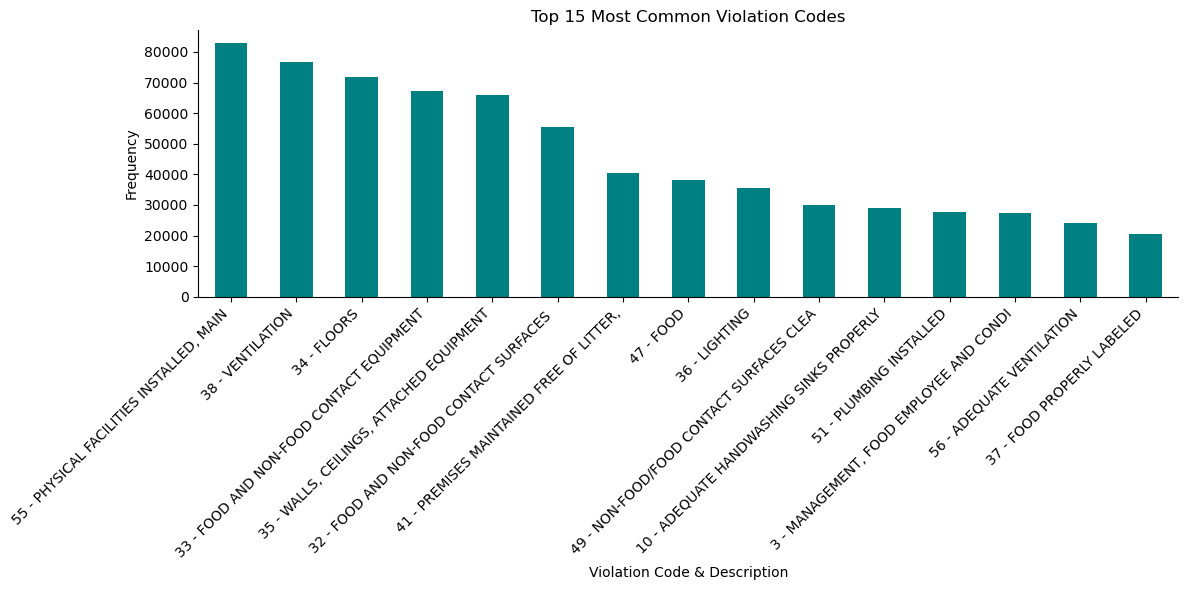

In [31]:
# Extract violation numbers and their textual descriptions
matches = inspections['violations'].dropna().str.extractall(r'(?:^|\|)\s*(\d+)\.\s*([A-Z\s,\/\-]+)')
matches[0] = matches[0].astype(int)

# Get the most common description for each code
code_to_desc = matches.groupby(0)[1].agg(lambda x: x.mode()[0].strip() if not x.empty else "Unknown")

print("--- Top 15 Most Common Violation Codes ---")
top_codes = matches[0].value_counts().head(15)

# Create labels combining code and description (truncated for fit)
labels = [f"{c} - {code_to_desc.get(c, 'Unknown')[:35]}" for c in top_codes.index]

ax = top_codes.plot(kind='bar', title='Top 15 Most Common Violation Codes', color='teal', figsize=(12, 6))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlabel('Violation Code & Description')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Facility Inspection Cadence

Do we have enough history per facility to build sequential features? Let's check how many inspections a typical license receives.

--- Inspections per Facility (License) ---
Facilities with 1 inspection: 25.2%
Facilities with 2-4 inspections: 32.8%
Facilities with 5+ inspections: 42.0%



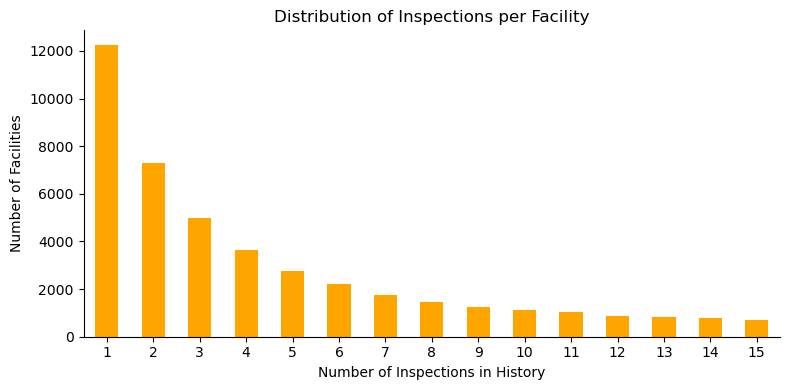

In [32]:
# Inspections per license
cadence = inspections.groupby('license_').size()

print("--- Inspections per Facility (License) ---")
print(f"Facilities with 1 inspection: {(cadence == 1).mean():.1%}")
print(f"Facilities with 2-4 inspections: {((cadence >= 2) & (cadence <= 4)).mean():.1%}")
print(f"Facilities with 5+ inspections: {(cadence >= 5).mean():.1%}\n")

ax = cadence.value_counts().sort_index().head(15).plot(kind='bar', title='Distribution of Inspections per Facility', color='orange', figsize=(8, 4))
ax.set_xlabel('Number of Inspections in History')
ax.set_ylabel('Number of Facilities')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Inspection EDA takeaways**

- The inspection data is usable as a label source, but not every `results` value is a trainable food-safety outcome.
- `Fail` and `Pass w/ Conditions` rates over time are useful drift checks before modeling.
- The model should avoid treating administrative outcomes such as `No Entry` or `Out of Business` as clean negatives.

## 2. 311 Service Requests — food-safety-relevant complaints

Source: https://data.cityofchicago.org/Service-Requests/311-Service-Requests/v6vf-nfxy

The full 311 table has ~14M rows across 100+ request types — almost all of which are irrelevant to food safety (potholes, traffic signals, etc.). We pull only the types that plausibly correlate with food-safety risk, since 2019 (matching our modeling window).

Two tiers of relevance:
- **Direct food-safety**: `Restaurant Complaint`, `Pushcart Food Vendor Complaint`
- **Ambient sanitation signal** (rodents, garbage, dumping): hyperlocal proxies for unsanitary conditions near food establishments

In [9]:
# SR types we care about. Discovered by querying $select=sr_type,count(*) on the API.
RELEVANT_SR_TYPES = [
    'Restaurant Complaint',
    'Pushcart Food Vendor Complaint',
    'Rodent Baiting/Rat Complaint',
    'Sanitation Code Violation',
    'Garbage Cart Maintenance',
    'Missed Garbage Pick-Up Complaint',
    'Fly Dumping Complaint',
    'Dead Animal Pick-Up Request',
]

def _fetch_311():
    # 311 since 2019 across these 8 types is ~1.1M rows. Two things we need:
    # 1) Keyset pagination on created_date (offset-pagination times out past ~500k).
    # 2) Dedupe on sr_number (each SR has a unique number) — the table contains a
    #    nested 'location' dict column that breaks the default drop_duplicates().
    # 3) shard_dir → each page is written to disk as it arrives, so if anything
    #    later fails we resume from where we left off instead of re-pulling 15 min.
    quoted = ', '.join(f"'{t}'" for t in RELEVANT_SR_TYPES)
    return fetch_soda_keyset(
        DATASETS['complaints_311'],
        cursor_col='created_date',
        cursor_start='2019-01-01T00:00:00',
        where_extra=f'sr_type IN ({quoted})',
        dedupe_on='sr_number',
        shard_dir=DATA_DIR / '_partial_complaints_311',
    )

complaints = load_or_fetch('complaints_311', _fetch_311)
complaints['created_date'] = pd.to_datetime(complaints['created_date'])
if 'closed_date' in complaints.columns:
    complaints['closed_date'] = pd.to_datetime(complaints['closed_date'], errors='coerce')
if 'latitude' in complaints.columns:
    complaints['latitude']  = pd.to_numeric(complaints['latitude'],  errors='coerce')
    complaints['longitude'] = pd.to_numeric(complaints['longitude'], errors='coerce')

peek(complaints, '311 Complaints (food-safety-relevant)')

↻ fetching complaints_311 from API...


  page 1: +50,000 rows (cursor=2019-01-01, 29.0s)


  page 2: +50,000 rows (cursor=2019-07-03, 33.4s)


  page 3: +50,000 rows (cursor=2019-10-04, 17.0s)


  page 4: +50,000 rows (cursor=2020-03-17, 15.4s)


...

  saved → ../data/raw/complaints_311.parquet  (1,123,070 rows)


=== 311 Complaints (food-safety-relevant) ===
shape:   1,123,070 rows × 38 cols


memory:  2227.8 MB
columns: ['sr_number', 'sr_type', 'sr_short_code', 'owner_department', 'status', 'origin', 'created_date', 'last_modified_date', 'closed_date', 'street_address', 'zip_code', 'street_number', 'street_direction', 'street_name', 'street_type', 'duplicate', 'legacy_record', 'community_area', 'ward', 'electrical_district', 'electricity_grid', 'police_sector', 'police_district', 'police_beat', 'precinct', 'sanitation_division_days', 'created_hour', 'created_day_of_week', 'created_month', 'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location', 'parent_sr_number', 'city', 'state', 'created_department']

— missing values (top 10) —


sanitation_division_days     99.3%
parent_sr_number            94.02%
electrical_district         79.85%
state                       65.29%
city                        65.29%
created_department          44.26%
zip_code                     13.4%
street_type                   1.3%
closed_date                  0.65%
electricity_grid              0.2%
dtype: object

— head(3) —


,sr_number,sr_type,sr_short_code,owner_department,status,origin,created_date,last_modified_date,closed_date,street_address,zip_code,street_number,street_direction,street_name,street_type,duplicate,legacy_record,community_area,ward,electrical_district,electricity_grid,police_sector,police_district,police_beat,precinct,sanitation_division_days,created_hour,created_day_of_week,created_month,x_coordinate,y_coordinate,latitude,longitude,location,parent_sr_number,city,state,created_department
0,SR19-00000730,Restaurant Complaint,HFB,Health,Completed,Internet,2019-01-01 08:49:29,2020-02-13T18:11:10.000,2019-03-19 11:23:51,903 N HALSTED ST,60642,903,N,HALSTED,ST,False,False,8,27,5,O020,2,18,1822,21,Tuesday,8,3,1,1170868.897,1906582.591,41.899141,-87.647845,"{'latitude': '41.89914141', 'longitude': '-87....",<NA>,<NA>,<NA>,<NA>
1,SR19-00001803,Restaurant Complaint,HFB,Health,Completed,Phone Call,2019-01-01 14:32:45,2020-02-13T18:11:27.000,2019-03-19 11:28:46,7100 S SOUTH CHICAGO AVE,60619,7100,S,SOUTH CHICAGO,AVE,False,False,69,5,12,S039,2,3,323,12,Friday,14,3,1,1182930.186,1857877.391,41.765218,-87.605062,"{'latitude': '41.765218', 'longitude': '-87.60...",<NA>,<NA>,<NA>,<NA>
2,SR19-00002507,Restaurant Complaint,HFB,Health,Completed,Internet,2019-01-01 18:27:43,2020-06-30T23:45:27.000,2019-03-19 11:31:45,7517 N Western AVE,60645,7517,N,Western,AVE,False,False,2,49,2,K004,1,24,2411,21,Monday,18,3,1,1159119.143,1949813.183,42.018018,-87.68981,"{'latitude': '42.018018', 'longitude': '-87.68...",<NA>,<NA>,<NA>,<NA>


### 311 API note

The 311 pull is the slowest fetch in this notebook because the filtered table is still large. The keyset pagination helper writes temporary shards during download, so interrupted pulls can be recovered locally, but the committed notebook keeps the full API fetch as the source of truth.

--- sr_type counts ---
sr_type
Garbage Cart Maintenance            371640
Rodent Baiting/Rat Complaint        366931
Sanitation Code Violation           107343
Dead Animal Pick-Up Request         103877
Fly Dumping Complaint                90810
Missed Garbage Pick-Up Complaint     58802
Restaurant Complaint                 22106
Pushcart Food Vendor Complaint        1561


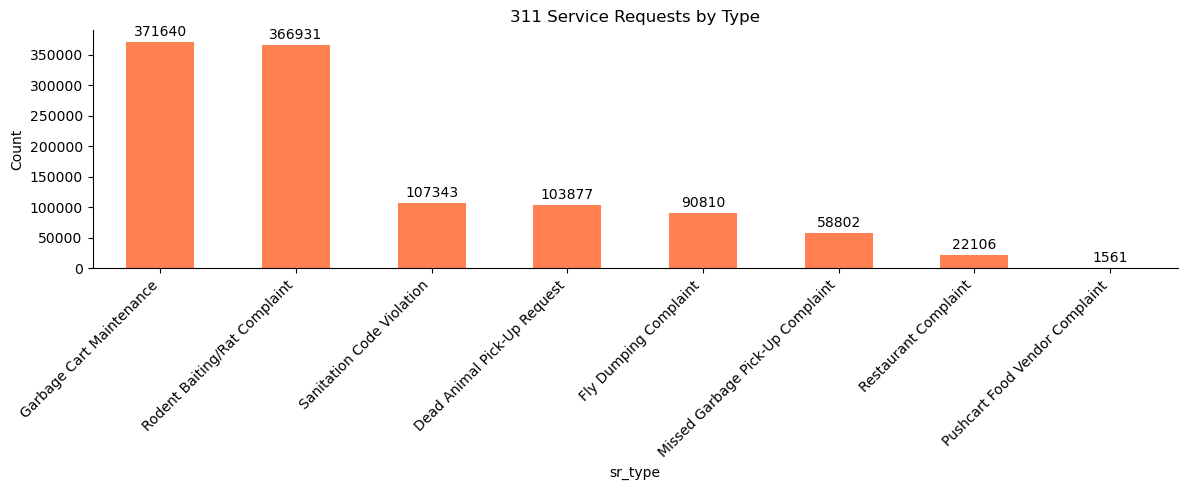


--- complaints per year ---


yr
2019    127908
2020    160835
2021    177479
2022    143357
2023    146041
2024    147935
2025    153779
2026     65736


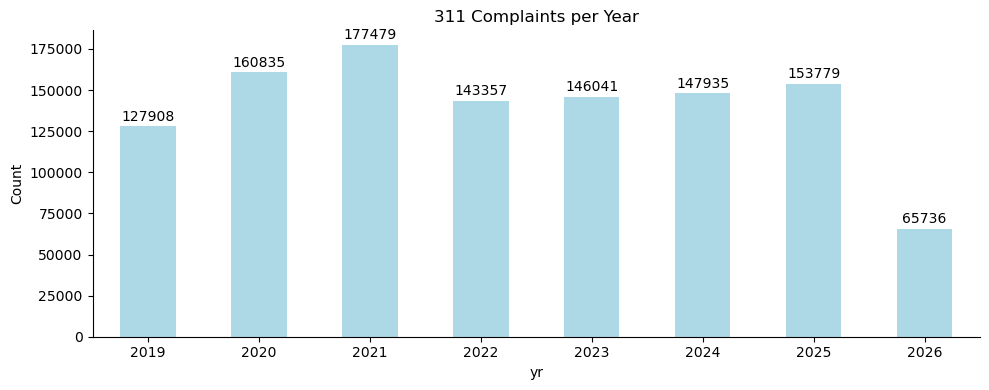

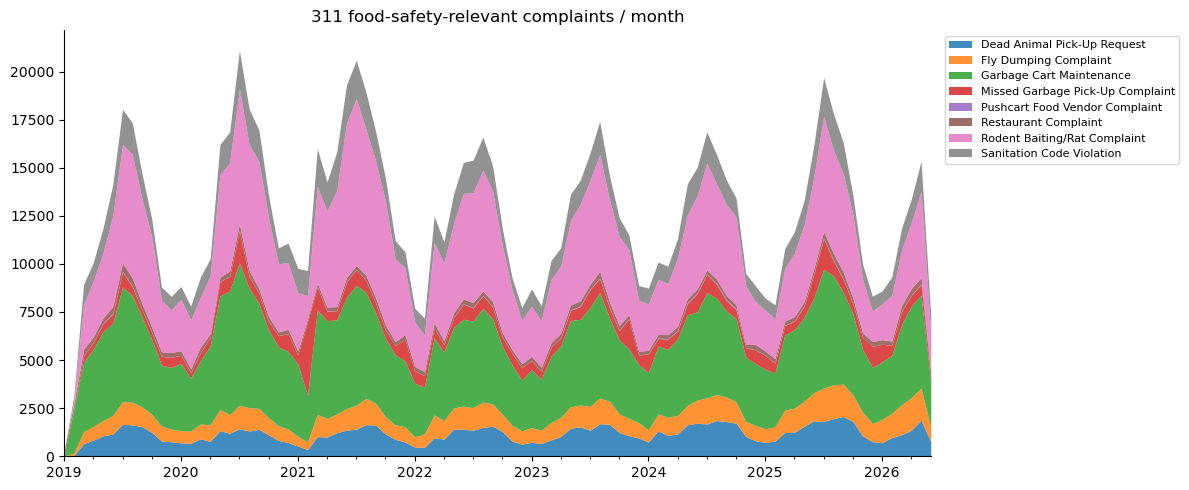

In [35]:
print('--- sr_type counts ---')
sr_counts = complaints['sr_type'].value_counts()
print(sr_counts.to_string())

# Bar chart for SR Types
ax_sr = sr_counts.plot(kind='bar', title='311 Service Requests by Type', color='coral', figsize=(12,5))
for c in ax_sr.containers: ax_sr.bar_label(c, padding=2)
ax_sr.set_xticklabels(ax_sr.get_xticklabels(), rotation=45, ha='right')
ax_sr.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('\n--- complaints per year ---')
by_year = complaints.assign(yr=complaints['created_date'].dt.year).groupby('yr').size()
print(by_year.to_string())

# Bar chart for Complaints per Year
ax_yr = by_year.plot(kind='bar', title='311 Complaints per Year', color='lightblue', figsize=(10,4))
for c in ax_yr.containers: ax_yr.bar_label(c, padding=2)
plt.xticks(rotation=0)
ax_yr.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Stacked monthly trend by sr_type — does any category spike around weather / COVID?
monthly = (complaints.assign(m=complaints['created_date'].dt.to_period('M').dt.to_timestamp())
           .groupby(['m', 'sr_type']).size().unstack(fill_value=0))
ax = monthly.plot.area(figsize=(12, 5), title='311 food-safety-relevant complaints / month',
                       alpha=0.85, linewidth=0)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8)
ax.set_xlabel(''); plt.tight_layout(); plt.show()

### 311 Spacial Validation

Before we build 300m radius features, we need to ensure the 311 data actually has valid coordinates and check the volume of legacy records.

In [34]:
print("--- 311 Geocoding & Quality Check ---")
missing_geo = complaints['latitude'].isna().mean()
print(f"Missing Latitude/Longitude: {missing_geo:.1%} of complaints")

if 'legacy_record' in complaints.columns:
    # Usually legacy records lack full standard detail, flag them
    is_legacy = complaints['legacy_record'].astype(str).str.lower() == 'true'
    print(f"Legacy Records: {is_legacy.mean():.1%} of complaints")

if 'duplicate' in complaints.columns:
    is_dup = complaints['duplicate'].astype(str).str.lower() == 'true'
    print(f"Marked as Duplicate: {is_dup.mean():.1%} of complaints")

--- 311 Geocoding & Quality Check ---
Missing Latitude/Longitude: 0.1% of complaints


Legacy Records: 0.0% of complaints


Marked as Duplicate: 6.0% of complaints


### 311 complaint signal quality

311 complaints are not outcomes. They are contextual signals that may capture nearby sanitation pressure, reporting intensity, and direct food-related complaint activity. Before using them as spatial features, we need to check whether the request types and coordinates are complete enough to support distance-based joins.

In [11]:
# Share of complaints by request type.
complaint_type_summary = (
    complaints['sr_type']
    .value_counts()
    .rename_axis('sr_type')
    .reset_index(name='n')
)

complaint_type_summary['share'] = (
    complaint_type_summary['n'] / complaint_type_summary['n'].sum()
)

complaint_type_summary

,sr_type,n,share
0,Garbage Cart Maintenance,371640,0.330914
1,Rodent Baiting/Rat Complaint,366931,0.326721
2,Sanitation Code Violation,107343,0.09558
3,Dead Animal Pick-Up Request,103877,0.092494
4,Fly Dumping Complaint,90810,0.080859
5,Missed Garbage Pick-Up Complaint,58802,0.052358
6,Restaurant Complaint,22106,0.019684
7,Pushcart Food Vendor Complaint,1561,0.00139


In [12]:
# Coordinate completeness matters for spatial joins to restaurants.
coord_cols = [c for c in ['latitude', 'longitude'] if c in complaints.columns]

if coord_cols:
    complaint_coord_quality = (
        complaints
        .assign(has_coordinates=complaints[coord_cols].notna().all(axis=1))
        .groupby('sr_type')
        .agg(
            n=('sr_type', 'size'),
            coordinate_complete_share=('has_coordinates', 'mean'),
        )
        .sort_values('n', ascending=False)
    )
    display(complaint_coord_quality.round(3))
else:
    print('No latitude/longitude columns found in complaints data.')

,n,coordinate_complete_share
sr_type,,
Garbage Cart Maintenance,371640,0.999
Rodent Baiting/Rat Complaint,366931,0.999
Sanitation Code Violation,107343,0.999
Dead Animal Pick-Up Request,103877,0.998
Fly Dumping Complaint,90810,0.999
Missed Garbage Pick-Up Complaint,58802,0.999
Restaurant Complaint,22106,0.998
Pushcart Food Vendor Complaint,1561,0.999


In [13]:
# Direct food complaint vs ambient sanitation proxy.
DIRECT_FOOD_SR_TYPES = {
    'Restaurant Complaint',
    'Pushcart Food Vendor Complaint',
}

complaints_signal = complaints.assign(
    signal_group=complaints['sr_type'].apply(
        lambda x: 'Direct food complaint'
        if x in DIRECT_FOOD_SR_TYPES
        else 'Ambient sanitation proxy'
    )
)

signal_summary = (
    complaints_signal
    .groupby('signal_group')
    .agg(
        n=('sr_type', 'size'),
        first_date=('created_date', 'min'),
        last_date=('created_date', 'max'),
    )
)

signal_summary['share'] = signal_summary['n'] / signal_summary['n'].sum()
signal_summary

,n,first_date,last_date,share
signal_group,,,,
Ambient sanitation proxy,1099403,2019-01-02 15:01:47,2026-06-13 15:18:47,0.978927
Direct food complaint,23667,2019-01-01 08:49:29,2026-06-13 14:22:49,0.021073


**311 EDA takeaways**

- Direct restaurant/pushcart complaints are closest to food-safety risk.
- Rodent, sanitation, garbage, dumping, and dead animal requests are broader neighborhood sanitation proxies.
- Coordinate completeness is important because downstream features will count complaints near a restaurant within a time window.
- 311 volume can reflect resident reporting behavior, so these features should be treated as contextual risk signals rather than ground truth.

## 3. Business Licenses — Current Active

Source: https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses-Current-Active/uupf-x98q

The snapshot of currently-active licenses. We want this for two reasons:
1. **Coordinates and community area** for every active establishment — fills the geographic gaps in the inspections table.
2. **Operator-level entity resolution** via `legal_name` / `account_number` — lets us link one owner to multiple licenses (a powerful feature we discussed).

In [14]:
def _fetch_licenses_current():
    # Small enough (~80k) to load all and filter in pandas, keeps the loader simple.
    return fetch_soda(
        DATASETS['licenses_current'],
        order='license_number ASC',
    )

licenses_current = load_or_fetch('licenses_current', _fetch_licenses_current)
for col in ['license_start_date', 'expiration_date', 'date_issued']:
    if col in licenses_current.columns:
        licenses_current[col] = pd.to_datetime(licenses_current[col], errors='coerce')
for col in ['latitude', 'longitude']:
    if col in licenses_current.columns:
        licenses_current[col] = pd.to_numeric(licenses_current[col], errors='coerce')

peek(licenses_current, 'Licenses (current active)')

↻ fetching licenses_current from API...


  page 1: +50,000 rows (cum 50,000, 12.6s)


  page 2: +4,980 rows (cum 54,980, 2.1s)


  saved → ../data/raw/licenses_current.parquet  (54,980 rows)
=== Licenses (current active) ===
shape:   54,980 rows × 36 cols


memory:  107.6 MB
columns: ['id', 'license_id', 'account_number', 'site_number', 'legal_name', 'doing_business_as_name', 'address', 'city', 'state', 'zip_code', 'ward', 'precinct', 'ward_precinct', 'police_district', 'community_area', 'community_area_name', 'neighborhood', 'license_code', 'license_description', 'business_activity_id', 'business_activity', 'license_number', 'application_type', 'application_requirements_complete', 'payment_date', 'conditional_approval', 'license_start_date', 'expiration_date', 'license_approved_for_issuance', 'date_issued', 'license_status', 'ssa', 'latitude', 'longitude', 'location', 'application_created_date']

— missing values (top 10) —
application_created_date    78.95%
ssa                         73.17%
precinct                     8.07%
longitude                    8.06%
location                     8.06%
latitude                     8.06%
neighborhood                 7.97%
community_area_name          7.91%
community_area                7.9%
ward

,id,license_id,account_number,site_number,legal_name,doing_business_as_name,address,city,state,zip_code,ward,precinct,ward_precinct,police_district,community_area,community_area_name,neighborhood,license_code,license_description,business_activity_id,business_activity,license_number,application_type,application_requirements_complete,payment_date,conditional_approval,license_start_date,expiration_date,license_approved_for_issuance,date_issued,license_status,ssa,latitude,longitude,location,application_created_date
0,149-20250716,3026672,17,1,"THOMAS J. FOX ENTERPRISES, INC.",FOX'S BEVERLY PUB,9956 S WESTERN AVE,CHICAGO,IL,60643,19,53,19-53,22,72,BEVERLY,BEVERLY,1006,Retail Food Establishment,775,Retail Sales of Perishable Foods,149,RENEW,2025-05-15T00:00:00.000,2025-07-04T00:00:00.000,N,2025-07-16,2027-07-15,2025-07-04T00:00:00.000,2025-07-07,AAI,20,41.712012,-87.681935,"{'type': 'Point', 'coordinates': [-87.68193540...",<NA>
1,150-20250716,3026671,17,1,"THOMAS J. FOX ENTERPRISES, INC.",FOX'S BEVERLY PUB,9956 S WESTERN AVE,CHICAGO,IL,60643,19,53,19-53,22,72,BEVERLY,BEVERLY,1475,Consumption on Premises - Incidental Activity,638,Consumption of Liquor on Premises,150,RENEW,2025-05-15T00:00:00.000,2025-07-04T00:00:00.000,N,2025-07-16,2027-07-15,2025-07-04T00:00:00.000,2025-07-07,AAI,20,41.712012,-87.681935,"{'type': 'Point', 'coordinates': [-87.68193540...",<NA>
2,153-20250416,3012071,62471,1,"JAF, LTD.",JEFFERY PUB,7041 S JEFFERY BLVD,CHICAGO,IL,60649,5,40,5-40,3,43,SOUTH SHORE,SOUTH SHORE,1470,Tavern,829,Tavern - Consumption of Liquor on Premises,153,RENEW,2025-02-15T00:00:00.000,2025-04-14T00:00:00.000,N,2025-04-16,2027-04-15,2025-04-14T00:00:00.000,2025-04-14,AAI,42,41.766818,-87.576171,"{'type': 'Point', 'coordinates': [-87.57617082...",<NA>


In [15]:
# Which license_descriptions are food-related? These are the rows we'll actually use
# downstream — restaurants, food prep, taverns, food sellers.
FOOD_LICENSE_KEYWORDS = ['food', 'restaurant', 'tavern', 'liquor', 'kitchen']

desc = licenses_current['license_description'].fillna('').str.lower()
food_mask = desc.str.contains('|'.join(FOOD_LICENSE_KEYWORDS), regex=True, na=False)

food_licenses = licenses_current[food_mask]
print(f'Total active licenses:        {len(licenses_current):,}')
print(f'Food-related active licenses: {len(food_licenses):,} ({food_mask.mean():.1%})')

print('\n--- top food license types ---')
print(food_licenses['license_description'].value_counts().head(15).to_string())

Total active licenses:        54,980
Food-related active licenses: 14,340 (26.1%)

--- top food license types ---
license_description
Retail Food Establishment                              11513
Shared Kitchen User (Long Term)                          814
Tavern                                                   803
Wholesale Food Establishment                             404
Caterer's Liquor License                                 286
Mobile Food License                                      190
Special Event Food                                       179
Food - Shared Kitchen - Supplemental                     118
Food - Shared Kitchen                                     19
Special Event Liquor                                      12
Retail Food - Seasonal Lakefront Food Establishment        1
Shared Kitchen User (Short Term)                           1


### Current license coverage and active restaurant universe

The current license table helps identify the active food-establishment universe and provides address/location metadata. This is useful for the app view because users will search for currently operating restaurants, but it should not be the only source for historical modeling because older inspected restaurants may no longer appear in the current active snapshot.

In [16]:
# Current active food-license geography/metadata completeness.
current_license_quality_cols = [
    c for c in ['latitude', 'longitude', 'license_start_date', 'expiration_date', 'legal_name', 'account_number']
    if c in food_licenses.columns
]

current_license_quality = (
    food_licenses[current_license_quality_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename('missing_pct')
    .to_frame()
)

current_license_quality

,missing_pct
latitude,2.64
longitude,2.64
license_start_date,0.00
expiration_date,0.00
legal_name,0.00
account_number,0.00


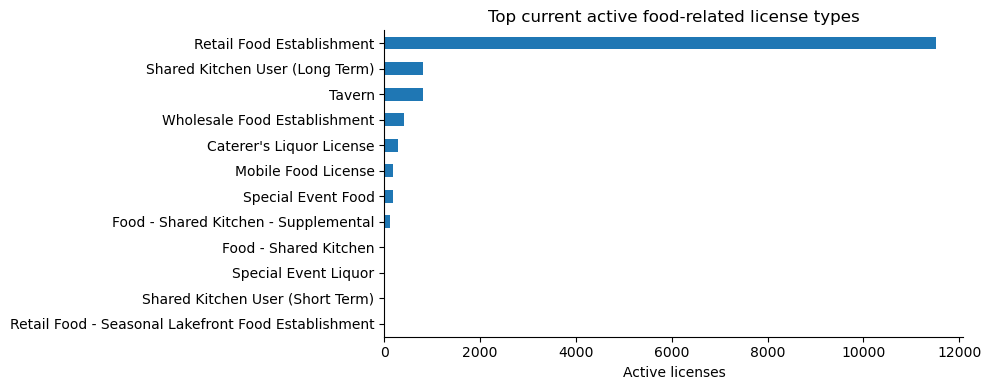

In [17]:
# Which active food license types dominate?
top_current_food_license_types = (
    food_licenses['license_description']
    .value_counts()
    .head(12)
)

ax = top_current_food_license_types.sort_values().plot.barh(
    title='Top current active food-related license types'
)
ax.set_xlabel('Active licenses')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [18]:
# Potential operator-level feature: one legal/account entity may own multiple licenses.
if 'account_number' in food_licenses.columns:
    operator_license_counts = (
        food_licenses
        .dropna(subset=['account_number'])
        .groupby('account_number')
        .agg(
            n_active_food_licenses=('license_number', 'nunique'),
            legal_name=('legal_name', 'first') if 'legal_name' in food_licenses.columns else ('account_number', 'first'),
        )
        .sort_values('n_active_food_licenses', ascending=False)
    )

    operator_license_counts.head(10)
else:
    print('account_number not available in current licenses.')

### Geographic Concentration

Where are these active food licenses concentrated? We can look at the top ZIP codes to get a sense of neighborhood density.

--- Top 15 ZIP Codes by Active Food Licenses ---


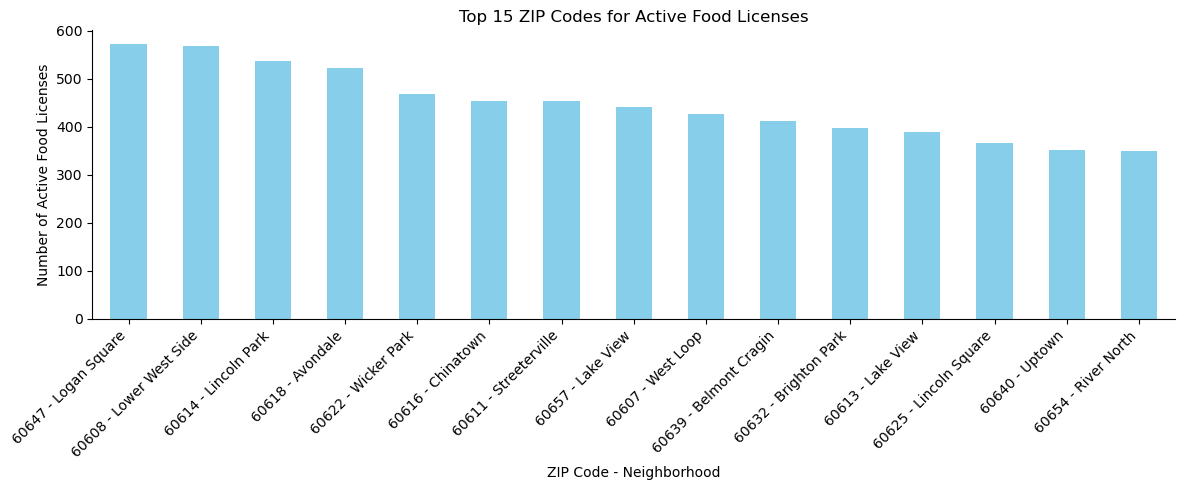

In [36]:
# Top 15 ZIP Codes by Active Food Licenses
top_zips = food_licenses['zip_code'].value_counts().head(15)

# Map ZIP codes to the most common neighborhood in that ZIP
zip_to_neighb = food_licenses.dropna(subset=['zip_code', 'neighborhood']).groupby('zip_code')['neighborhood'].agg(lambda x: x.mode()[0] if not x.empty else 'Unknown')
labels = [f"{z} - {zip_to_neighb.get(z, 'Unknown').title()}" for z in top_zips.index]
top_zips.index = labels

print("--- Top 15 ZIP Codes by Active Food Licenses ---")
ax = top_zips.plot(kind='bar', title='Top 15 ZIP Codes for Active Food Licenses', color='skyblue', figsize=(12, 5))
ax.set_xlabel('ZIP Code - Neighborhood')
ax.set_ylabel('Number of Active Food Licenses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Multi-License Operators

Can we link one owner to multiple locations? The `account_number` and `legal_name` columns allow us to build operator-level risk features.

--- Operator Concentration ---
Operators with exactly 1 active food license: 83.9%
Operators with 2+ active food licenses:       16.1%

--- Top 10 Operators by Active Food Licenses (legal_name) ---


,Active Licenses
legal_name,
STARBUCKS CORPORATION,126
"COMPASS GROUP USA, INC.",70
"FAMILY DOLLAR, LLC",69
WALGREEN CO.,61
"DOLLAR TREE STORES, INC.",60
"HOST INTERNATIONAL, INC.",53
"BOND DRUG COMPANY OF ILLINOIS, LLC",46
"POTBELLY SANDWICH WORKS, LLC",45
"ARAMARK EDUCATIONAL SERVICES, LLC",45



--- Which Active License Types Match Inspections Most? ---


,Inspection Count
license_description,
Retail Food Establishment,122990
Children's Services Facility License,6782
Consumption on Premises - Incidental Activity,3258
Regulated Business License,1320
Package Goods,1071
Tavern,904
Mobile Food License,667
Outdoor Patio,453
Caterer's Liquor License,288



--- Geographic Fairness: Failure Rate by Community Area ---


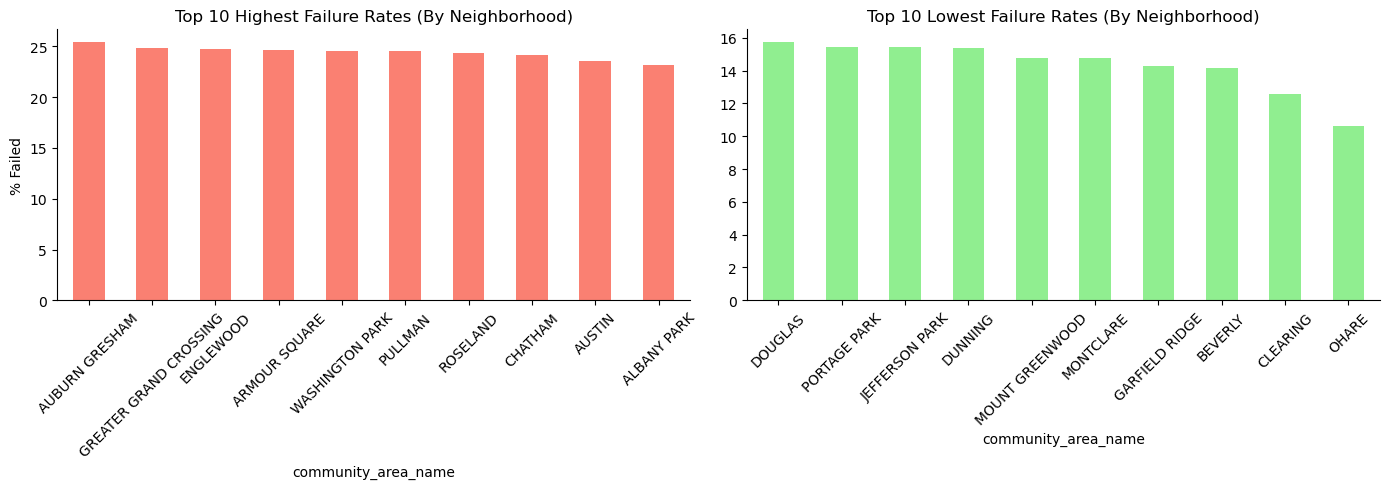

In [37]:
# Multi-license operators based on account_number
operators = food_licenses.groupby('account_number').size()

print("--- Operator Concentration ---")
print(f"Operators with exactly 1 active food license: {(operators == 1).mean():.1%}")
print(f"Operators with 2+ active food licenses:       {(operators > 1).mean():.1%}\n")

print("--- Top 10 Operators by Active Food Licenses (legal_name) ---")
display(food_licenses['legal_name'].value_counts().head(10).to_frame('Active Licenses'))

# --- NEW: License Type Matching ---
print("\n--- Which Active License Types Match Inspections Most? ---")
insp_lic_desc = inspections.merge(licenses_current[['license_number', 'license_description', 'community_area_name']],
                                  left_on='license_', right_on='license_number', how='inner')
display(insp_lic_desc['license_description'].value_counts().head(10).to_frame('Inspection Count'))

# --- NEW: Geographic Fairness (Missing EDA) ---
print("\n--- Geographic Fairness: Failure Rate by Community Area ---")
ca_fails = insp_lic_desc.groupby('community_area_name')['results'].apply(lambda x: (x == 'Fail').mean() * 100)
ca_counts = insp_lic_desc.groupby('community_area_name').size()

# Filter to areas with at least 100 inspections for stable rates
valid_cas = ca_counts[ca_counts >= 100].index
ca_fails = ca_fails[valid_cas].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ca_fails.head(10).plot(kind='bar', ax=axes[0], color='salmon', title='Top 10 Highest Failure Rates (By Neighborhood)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('% Failed')

ca_fails.tail(10).plot(kind='bar', ax=axes[1], color='lightgreen', title='Top 10 Lowest Failure Rates (By Neighborhood)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Current license EDA takeaways**

- Current licenses are useful for active restaurant metadata and app-facing lookup.
- Coordinate and license-date completeness determine how much enrichment we can use downstream.
- `account_number` / `legal_name` may support operator-level features, such as whether one owner has multiple active food licenses.

## 4. Business Licenses — Historical

Source: https://data.cityofchicago.org/Community-Economic-Development/Business-licenses/vgg9-bn8p

The full history of every license issuance, renewal, and status change since 2002. It's ~2M rows — far too big for an "all data" pull — so we filter server-side to food-related licenses only, which is what we'll actually use.

Key fields:
- `license_number` — joins to `license_` in food inspections (the bridge between the two datasets)
- `application_type` (ISSUE / RENEW / C_LOC / C_CAPA) — tells us new vs renewed
- `license_status` (AAI = Active / AAC = Cancelled / REV = Revoked / etc.)
- `license_start_date`, `expiration_date` — for computing **license age** (a Tier-1 feature)

In [19]:
def _fetch_licenses_historical():
    # Filter server-side to food/restaurant/tavern/liquor licenses to keep this tractable.
    # upper() makes it case-insensitive; like-pattern matching is supported by SoQL.
    where = (
        "(upper(license_description) like '%FOOD%'"
        " OR upper(license_description) like '%RESTAURANT%'"
        " OR upper(license_description) like '%TAVERN%'"
        " OR upper(license_description) like '%LIQUOR%'"
        " OR upper(license_description) like '%KITCHEN%')"
    )
    return fetch_soda(
        DATASETS['licenses_historical'],
        where=where,
        order='date_issued ASC, license_number ASC',
    )

licenses_hist = load_or_fetch('licenses_historical', _fetch_licenses_historical)
for col in ['license_start_date', 'expiration_date', 'date_issued', 'payment_date']:
    if col in licenses_hist.columns:
        licenses_hist[col] = pd.to_datetime(licenses_hist[col], errors='coerce')

peek(licenses_hist, 'Licenses (historical, food-related)')

↻ fetching licenses_historical from API...


  page 1: +50,000 rows (cum 50,000, 6.7s)


  page 2: +50,000 rows (cum 100,000, 10.2s)


  page 3: +14,080 rows (cum 114,080, 3.9s)


  saved → ../data/raw/licenses_historical.parquet  (114,080 rows)
=== Licenses (historical, food-related) ===
shape:   114,080 rows × 14 cols


memory:  72.6 MB
columns: ['legal_name', 'doing_business_as_name', 'address', 'city', 'zip_code', 'license_code', 'license_description', 'license_number', 'application_type', 'payment_date', 'license_start_date', 'expiration_date', 'date_issued', 'license_status']

— missing values (top 10) —
payment_date              0.48%
zip_code                   0.1%
license_start_date        0.06%
legal_name                 0.0%
doing_business_as_name     0.0%
address                    0.0%
city                       0.0%
license_code               0.0%
license_description        0.0%
license_number             0.0%
dtype: object

— head(3) —


,legal_name,doing_business_as_name,address,city,zip_code,license_code,license_description,license_number,application_type,payment_date,license_start_date,expiration_date,date_issued,license_status
0,"JEWEL FOOD STORES, INC.",Jewel Food Store #3632,3630 N SOUTHPORT AVE 1ST AND 2ND FLOORS,CHICAGO,60613,1006,Retail Food Establishment,2037181,ISSUE,2010-09-21,2010-10-15,2015-01-15,2010-10-15,AAI
1,"BLESSED MANUFACTURING, LLC","BLESSED MANUFACTURING, LLC",3333-3351 N ELSTON AVE 1,CHICAGO,60618,1007,Wholesale Food Establishment,2079587,ISSUE,2011-02-23,2011-03-11,2015-03-15,2011-03-11,AAI
2,"CARNICERIA Y FRUTERIA ""LOS ALTOS"" INC.","CARNICERIA Y FRUTERIA ""LOS ALTOS""",2959 W 40TH ST 1ST FLOOR 1,CHICAGO,60632,1006,Retail Food Establishment,1802424,RENEW,2011-03-15,2011-06-16,2013-06-15,2011-03-16,AAI


--- license_description (top 15) ---
license_description
Retail Food Establishment                                       84756
Special Event Food                                               8142
Tavern                                                           6532
Wholesale Food Establishment                                     4020
Shared Kitchen User (Long Term)                                  3346
Special Event Liquor                                             2736
Mobile Food License                                              1961
Caterer's Liquor License                                         1721
Food - Shared Kitchen - Supplemental                              526
Shared Kitchen User (Short Term)                                  118
Food - Shared Kitchen                                              89
Caterer's Registration (Liquor)                                    34
Retail Food Est.-Supplemental License for Dog-Friendly Areas       32
Pop-Up Food Est. User - Tier I   

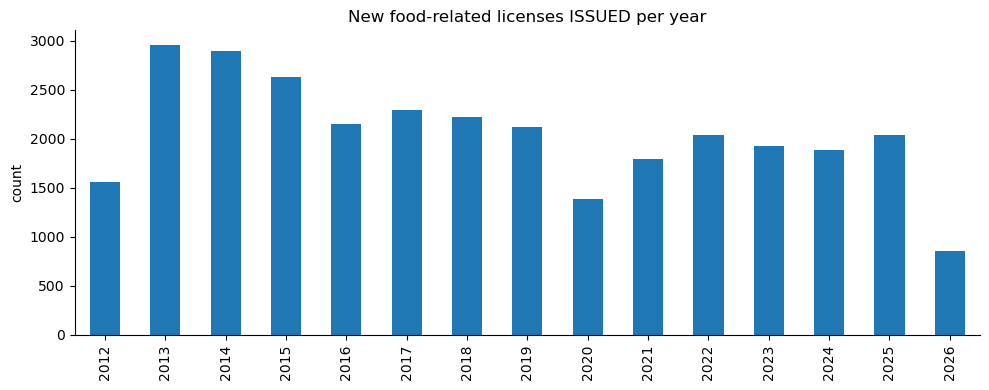

In [20]:
print('--- license_description (top 15) ---')
print(licenses_hist['license_description'].value_counts().head(15).to_string())

print('\n--- application_type ---')
print(licenses_hist['application_type'].value_counts().to_string())

print('\n--- license_status (top 10) ---')
print(licenses_hist['license_status'].value_counts().head(10).to_string())

# New food licenses issued per year — proxy for food-establishment turnover
issued = (licenses_hist[licenses_hist['application_type'] == 'ISSUE']
          .assign(yr=licenses_hist['date_issued'].dt.year)
          .groupby('yr').size())
ax = issued.tail(15).plot.bar(title='New food-related licenses ISSUED per year')
ax.set_xlabel(''); ax.set_ylabel('count'); plt.tight_layout(); plt.show()

### Historical license features

The historical license table turns a point-in-time inspection into richer business context. The most important feature candidates are license age, renewal history, and status history. These are especially useful because they are available before a future inspection outcome and can be computed without leaking the label.

In [21]:
# Historical license depth: how many history rows exist per license?
license_history_depth = (
    licenses_hist
    .groupby('license_number')
    .size()
    .describe()
)

license_history_depth

count    42866.000000
mean         2.661317
std          2.256817
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max         13.000000
dtype: float64

In [22]:
licenses_hist_sorted = licenses_hist.sort_values(['license_number', 'date_issued'])

license_age_base = (
    licenses_hist_sorted
    .groupby('license_number')
    .agg(
        first_license_start=('license_start_date', 'min'),
        first_issued=('date_issued', 'min'),
        last_expiration=('expiration_date', 'max'),
        n_license_history_rows=('license_number', 'size'),
        n_application_types=('application_type', 'nunique'),
        latest_status=('license_status', 'last'),
    )
)

license_age_base.head()

,first_license_start,first_issued,last_expiration,n_license_history_rows,n_application_types,latest_status
license_number,,,,,,
1000049,2012-05-16,2012-04-13,2018-05-15,3,1,AAI
1000125,2012-11-16,2012-10-12,2014-11-15,1,1,AAI
1000350,2012-07-16,2012-07-13,2021-07-15,4,1,AAI
1000572,2012-03-16,2012-02-23,2028-03-15,8,1,AAI
1000612,2012-02-16,2012-01-26,2020-02-15,4,1,AAI


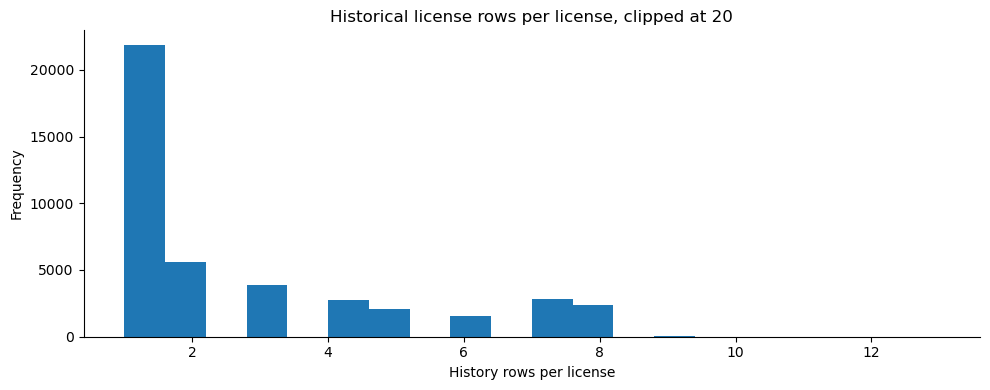

In [23]:
# Distribution of historical depth per license.
ax = (
    license_age_base['n_license_history_rows']
    .clip(upper=20)
    .plot.hist(
        bins=20,
        title='Historical license rows per license, clipped at 20'
    )
)
ax.set_xlabel('History rows per license')
plt.tight_layout()
plt.show()

**Historical license EDA takeaways**

- Historical licenses can support leak-free business-history features such as license age and renewal count.
- Most licenses should have only a small number of history rows, while multi-row licenses capture renewals, changes, or status updates.
- These features are safer than inspection-result-derived features because they are business metadata rather than future outcomes.

## 5. How the four datasets connect

These are the joins we'll rely on in the feature pipeline. Each has a known sharp edge — calling them out now saves a debugging week later.

| From | → | To | Key | Gotcha |
|---|---|---|---|---|
| Food Inspections | → | Business Licenses (hist) | `license_` ↔ `license_number` | `license_ = '0'` is a placeholder used for unlicensed events — drop before joining |
| Food Inspections | → | Business Licenses (current) | `license_` ↔ `license_number` | Many old inspections are at facilities whose license has since expired — they won't be in *current* |
| Food Inspections | ↔ | 311 Complaints | `latitude`/`longitude` spatial join | 311 lat/lon is geocoded from the address and can be coarse (block-centroid) — use a 100–300m buffer, not a literal point match |
| Business Licenses (current) | ↔ | Business Licenses (hist) | `license_number` | Current is a snapshot of *active* rows; historical has every issuance/renewal — join hist's earliest `license_start_date` for **license age**, which is a strong feature |

The next two cells sanity-check the most important join (inspections ↔ historical licenses) so we know what % of inspections we can actually enrich with license metadata.

In [24]:
# How much overlap exists between inspections.license_ and licenses_hist.license_number?
insp_lic = (inspections.loc[~inspections['license_'].isin(['', '0']), 'license_']
            .dropna().astype(str).unique())
hist_lic = licenses_hist['license_number'].dropna().astype(str).unique()

insp_set = set(insp_lic)
hist_set = set(hist_lic)
shared = insp_set & hist_set

print(f'Unique licenses in inspections (food):       {len(insp_set):,}')
print(f'Unique licenses in historical (food filter): {len(hist_set):,}')
print(f'Overlap (inspections joinable to history):   {len(shared):,}')
print(f'Coverage = {len(shared)/len(insp_set):.1%} of inspection-side licenses match')

Unique licenses in inspections (food):       48,652
Unique licenses in historical (food filter): 42,866
Overlap (inspections joinable to history):   27,473
Coverage = 56.5% of inspection-side licenses match


In [25]:
# Tiny worked example: take 5 sample inspections, join to historical licenses, show
# the kinds of enrichments we'd get (license_description, dates, status).
sample = inspections[inspections['license_'].isin(list(shared)[:5])][
    ['inspection_id', 'license_', 'dba_name', 'inspection_date', 'results']
].drop_duplicates('license_').head(5)

enrichment = (licenses_hist[licenses_hist['license_number'].isin(sample['license_'])]
              .groupby('license_number')
              .agg(first_issued=('date_issued', 'min'),
                   last_renewal=('date_issued', 'max'),
                   n_history_rows=('license_number', 'size'),
                   license_description=('license_description', 'first'))
              .reset_index().rename(columns={'license_number': 'license_'}))

sample.merge(enrichment, on='license_', how='left')

,inspection_id,license_,dba_name,inspection_date,results,first_issued,last_renewal,n_history_rows,license_description
0,1336060,2254173,IYANZE,2013-06-12,Fail,2013-07-10,2017-10-16,3,Mobile Food License
1,2213921,2616792,"ONTARIO STREET OWNER, LLC",2018-09-06,Pass w/ Conditions,2018-09-26,2024-08-28,4,Retail Food Establishment
2,2229885,2564511,BELLWETHER MEETING HOUSE & EATERY,2018-10-18,Pass w/ Conditions,2020-02-26,2020-02-26,1,Caterer's Liquor License
3,2385230,2713558,FRUVE XPRESS JUICERY,2020-07-22,Pass,2020-08-03,2020-08-03,1,Retail Food Establishment
4,2619964,3031094,Dollop Coffee Co.,2025-07-02,Not Ready,2025-07-14,2026-03-23,2,Retail Food Establishment


### License Age & Inspection Cadence

Let's calculate the distribution of License Age at the time of inspection, and the typical gap in days between inspections for a single facility.

--- License Age Distribution ---


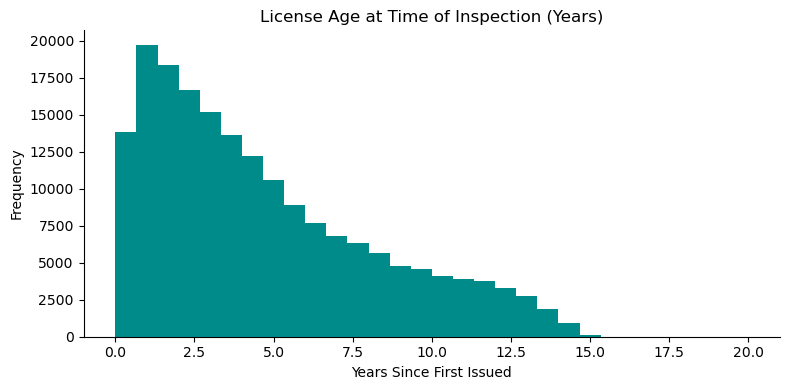


--- Days Between Inspections for the Same Facility ---


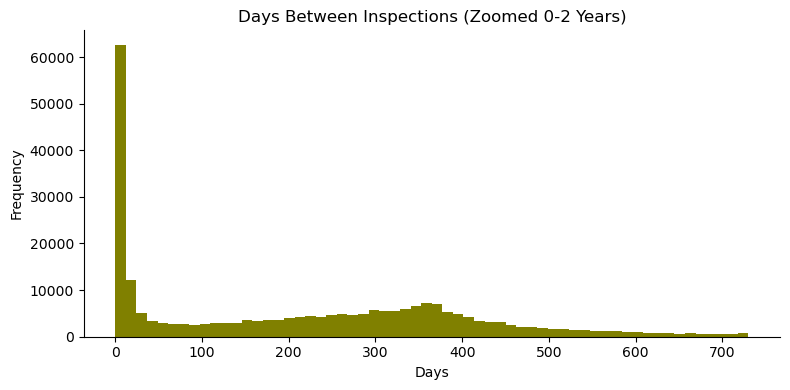

In [38]:
# 1. License Age at time of inspection
print("--- License Age Distribution ---")
all_first_issued = licenses_hist.groupby('license_number')['date_issued'].min().reset_index()
all_first_issued.rename(columns={'license_number': 'license_'}, inplace=True)

insp_enriched = inspections.merge(all_first_issued, on='license_', how='left')
insp_enriched['license_age_years'] = (insp_enriched['inspection_date'] - insp_enriched['date_issued']).dt.days / 365.25

ax = insp_enriched['license_age_years'].plot.hist(bins=30, range=(0, 20), title='License Age at Time of Inspection (Years)', color='darkcyan', figsize=(8, 4))
ax.set_xlabel('Years Since First Issued')
plt.tight_layout()
plt.show()

# 2. Days between inspections
print("\n--- Days Between Inspections for the Same Facility ---")
insp_sorted = inspections.sort_values(['license_', 'inspection_date'])
insp_sorted['days_since_last'] = insp_sorted.groupby('license_')['inspection_date'].diff().dt.days

ax2 = insp_sorted['days_since_last'].dropna().plot.hist(bins=60, range=(0, 730), title='Days Between Inspections (Zoomed 0-2 Years)', color='olive', figsize=(8, 4))
ax2.set_xlabel('Days')
plt.tight_layout()
plt.show()

### Pre/Post July 2018 Policy Change

Chicago implemented new food inspection rules in July 2018. Let's see if the baseline failure rate shifted significantly after this change.

In [39]:
print("--- Pre/Post July 2018 Policy Change Impact ---")
# Filter to Canvass (routine) inspections to control for inspection type changes
canvass_only = inspections[inspections['inspection_type'].str.lower().str.contains('canvass', na=False)].copy()
canvass_only['period'] = '1. Pre-July 2018'
canvass_only.loc[canvass_only['inspection_date'] >= '2018-07-01', 'period'] = '2. Post-July 2018'

policy_shift = canvass_only.groupby('period')['results'].apply(lambda x: (x == 'Fail').mean() * 100)
display(policy_shift.to_frame('% Failed (Canvass Only)'))

--- Pre/Post July 2018 Policy Change Impact ---


,% Failed (Canvass Only)
period,
1. Pre-July 2018,15.257167
2. Post-July 2018,18.283854


### Join coverage: license-level and inspection-row-level

The unique-license overlap tells us how many distinct facilities can be enriched. The row-level overlap tells us how much of the actual inspection training table can receive historical license features.

In [26]:
# Row-level joinability from inspections to historical licenses.
inspection_valid_license = inspections[
    ~inspections['license_'].isin(['', '0'])
].copy()

inspection_valid_license['joins_to_license_history'] = (
    inspection_valid_license['license_'].astype(str).isin(hist_set)
)

row_join_summary = pd.Series({
    'inspection_rows_total': len(inspections),
    'inspection_rows_with_valid_license': len(inspection_valid_license),
    'inspection_rows_joinable_to_history': inspection_valid_license['joins_to_license_history'].sum(),
    'valid_license_row_join_rate': inspection_valid_license['joins_to_license_history'].mean(),
})

row_join_summary.to_frame('value')

,value
inspection_rows_total,311775.00000
inspection_rows_with_valid_license,310975.00000
inspection_rows_joinable_to_history,237448.00000
valid_license_row_join_rate,0.76356


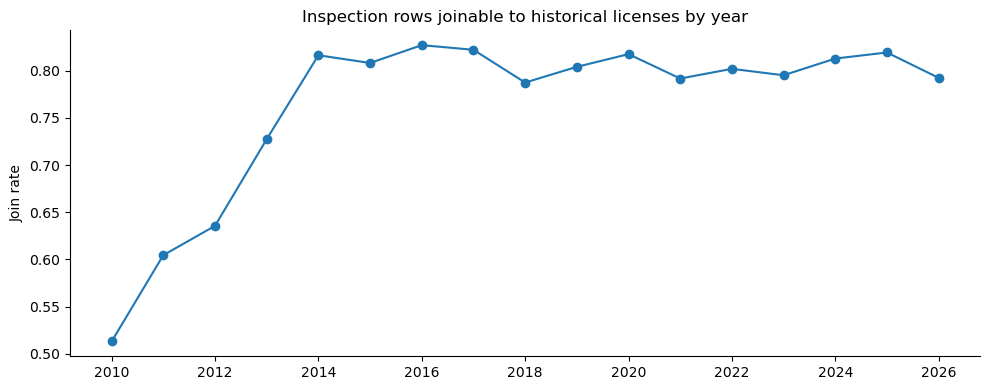

In [27]:
# Join coverage over time.
join_by_year = (
    inspection_valid_license
    .assign(year=inspection_valid_license['inspection_date'].dt.year)
    .groupby('year')
    .agg(
        n_inspection_rows=('inspection_id', 'size'),
        join_rate=('joins_to_license_history', 'mean'),
    )
)

ax = join_by_year['join_rate'].plot(
    marker='o',
    title='Inspection rows joinable to historical licenses by year'
)
ax.set_xlabel('')
ax.set_ylabel('Join rate')
plt.tight_layout()
plt.show()

**Join coverage takeaway**

If row-level join coverage is high, license-history features can be used broadly in the modeling table. If coverage drops in older years, that supports using 2019+ as the training window and treating older records mostly as burn-in/history.

## EDA summary for handoff

This notebook validates that the four source datasets are usable for the MVP modeling pipeline:

1. **Food inspections** provide the outcome source, but only some `results` values are modelable food-safety outcomes.
2. **311 complaints** provide contextual neighborhood and direct complaint signals, but should be treated as noisy proxy features rather than labels.
3. **Current licenses** help define active food establishments and support app-facing lookup.
4. **Historical licenses** support leak-free business-history features such as license age, renewal count, and status history.
5. The key join path is `inspections.license_` → `licenses_hist.license_number`; row-level coverage determines how broadly license features can be used.

## 6. What's next

With the four datasets loaded and cached, the next notebook (`02_feature_engineering.ipynb`) will build the modeling table:

1. **Inspection-level base table** — one row per inspection, target = `Fail` or `has_priority_violation`.
2. **Facility history features** (leak-free): prior fail count, prior critical-violation count, days since last inspection, rolling violation rate.
3. **License features**: license age (from historical), license type, currently-active flag.
4. **Neighborhood 311 features**: counts of rodent/sanitation/restaurant complaints within 300m and 90 days of each inspection.
5. **Geographic context**: community area, ZIP fail-rate (leak-free), spatial-neighbor fail rate.

Re-running this notebook is cheap — every dataset is cached under `data/raw/`. Delete the parquet to force a refresh.